# Assignment 04 — Wine Dataset: Dimensionality Reduction & Clustering

This notebook covers:
1. **Data import & wrangling** — load the Wine Quality dataset with pandas
2. **Dimensionality reduction** — PCA and t-SNE (two methods compared)
3. **Clustering** — K-Means and Agglomerative Clustering (two methods compared)
4. **Export** — save all results to an SQLite database for the D3 frontend


## Step 1: Import Libraries

In [11]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Step 2: Load the Wine Dataset

The Wine dataset (UCI ML Repository, ID 109) contains 178 wine samples from
three Italian cultivars, each described by 13 chemical attributes.

Reference: https://archive.ics.uci.edu/dataset/109/wine


In [12]:
# Column names taken from wine.names
columns = [
    'cultivar', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash',
    'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
    'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline'
]

# Read wine.data — comma-separated, no header row
wine = pd.read_csv('wine.data', header=None, names=columns)

print(f"Dataset shape: {wine.shape}  ({wine.shape[0]} samples, {wine.shape[1]} columns)")
wine.head()


Dataset shape: (178, 14)  (178 samples, 14 columns)


,cultivar,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


In [13]:
# Basic statistics
wine.describe().round(2)


,cultivar,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315,proline
count,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00,178.00
mean,1.94,13.00,2.34,2.37,19.49,99.74,2.30,2.03,0.36,1.59,5.06,0.96,2.61,746.89
std,0.78,0.81,1.12,0.27,3.34,14.28,0.63,1.00,0.12,0.57,2.32,0.23,0.71,314.91
min,1.00,11.03,0.74,1.36,10.60,70.00,0.98,0.34,0.13,0.41,1.28,0.48,1.27,278.00
25%,1.00,12.36,1.60,2.21,17.20,88.00,1.74,1.20,0.27,1.25,3.22,0.78,1.94,500.50
50%,2.00,13.05,1.87,2.36,19.50,98.00,2.36,2.13,0.34,1.56,4.69,0.96,2.78,673.50
75%,3.00,13.68,3.08,2.56,21.50,107.00,2.80,2.88,0.44,1.95,6.20,1.12,3.17,985.00
max,3.00,14.83,5.80,3.23,30.00,162.00,3.88,5.08,0.66,3.58,13.00,1.71,4.00,1680.00


In [14]:
# Class distribution
print("Class (cultivar) distribution:")
print(wine['cultivar'].value_counts().sort_index())

# Add human-readable cultivar name
wine['cultivar_name'] = wine['cultivar'].map({
    1: 'Cultivar 1',
    2: 'Cultivar 2',
    3: 'Cultivar 3'
})
print("\nCultivars:", wine['cultivar_name'].unique())


Class (cultivar) distribution:
cultivar
1    59
2    71
3    48
Name: count, dtype: int64

Cultivars: ['Cultivar 1' 'Cultivar 2' 'Cultivar 3']


## Step 3: Feature Standardization

All 13 chemical features are scaled to zero mean and unit variance
before applying any dimensionality reduction or clustering method.
This prevents high-range features (e.g. proline ~700–1700) from
dominating the distance calculations.


In [15]:
feature_cols = [
    'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
    'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
    'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline'
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(wine[feature_cols])

print(f"Feature matrix shape: {X_scaled.shape}")
print(f"Mean (should be ~0): {X_scaled.mean(axis=0).round(10)}")
print(f"Std  (should be ~1): {X_scaled.std(axis=0).round(2)}")


Feature matrix shape: (178, 13)
Mean (should be ~0): [-0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Step 4: Dimensionality Reduction

Two methods are applied and compared:
- **Method 1 — PCA** (Principal Component Analysis): linear, global structure
- **Method 2 — t-SNE** (t-distributed Stochastic Neighbor Embedding): non-linear, local structure


### 4a — Method 1: PCA

In [16]:
# ── PCA ──────────────────────────────────────────────────────────
# PCA finds orthogonal linear combinations of features that maximise
# the explained variance.  We reduce the 13-dimensional data to 2D.
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(X_scaled)

wine['pca_x'] = pca_coords[:, 0]
wine['pca_y'] = pca_coords[:, 1]

ev = pca.explained_variance_ratio_
print(f"PC1 explained variance: {ev[0]:.4f}  ({ev[0]*100:.1f} %)")
print(f"PC2 explained variance: {ev[1]:.4f}  ({ev[1]*100:.1f} %)")
print(f"Total (2 components):   {ev.sum():.4f}  ({ev.sum()*100:.1f} %)")


PC1 explained variance: 0.3620  (36.2 %)
PC2 explained variance: 0.1921  (19.2 %)
Total (2 components):   0.5541  (55.4 %)


In [17]:
# PCA loading plot — shows which features drive each principal component
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=['PC1', 'PC2']
)
print("PCA loadings (feature contributions):")
print(loadings.round(3).sort_values('PC1', key=abs, ascending=False))


PCA loadings (feature contributions):
                        PC1    PC2
flavanoids            0.423 -0.003
total_phenols         0.395  0.065
od280_od315           0.376 -0.164
proanthocyanins       0.313  0.039
nonflavanoid_phenols -0.299  0.029
hue                   0.297 -0.279
proline               0.287  0.365
malic_acid           -0.245  0.225
alcalinity_of_ash    -0.239 -0.011
alcohol               0.144  0.484
magnesium             0.142  0.300
color_intensity      -0.089  0.530
ash                  -0.002  0.316


### 4b — Method 2: t-SNE

In [18]:
# ── t-SNE ────────────────────────────────────────────────────────
# t-SNE optimises a 2-D layout so that similar high-dimensional points
# remain close together.  It captures non-linear, local neighbourhood
# structure but distances between distant clusters are not meaningful.
#
# Key hyperparameters:
#   perplexity  — roughly the number of nearest neighbours considered
#                 (5–50 is typical; 30 is a good default for ~178 points)
#   n_iter      — more iterations → more stable layout; 1000 is standard
tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    random_state=RANDOM_STATE
)
tsne_coords = tsne.fit_transform(X_scaled)

wine['tsne_x'] = tsne_coords[:, 0]
wine['tsne_y'] = tsne_coords[:, 1]

print("t-SNE projection computed.")
print(f"tsne_x range: [{wine['tsne_x'].min():.2f}, {wine['tsne_x'].max():.2f}]")
print(f"tsne_y range: [{wine['tsne_y'].min():.2f}, {wine['tsne_y'].max():.2f}]")


t-SNE projection computed.
tsne_x range: [-15.05, 14.56]
tsne_y range: [-9.41, 10.83]


### 4c — Visual Comparison of PCA vs t-SNE

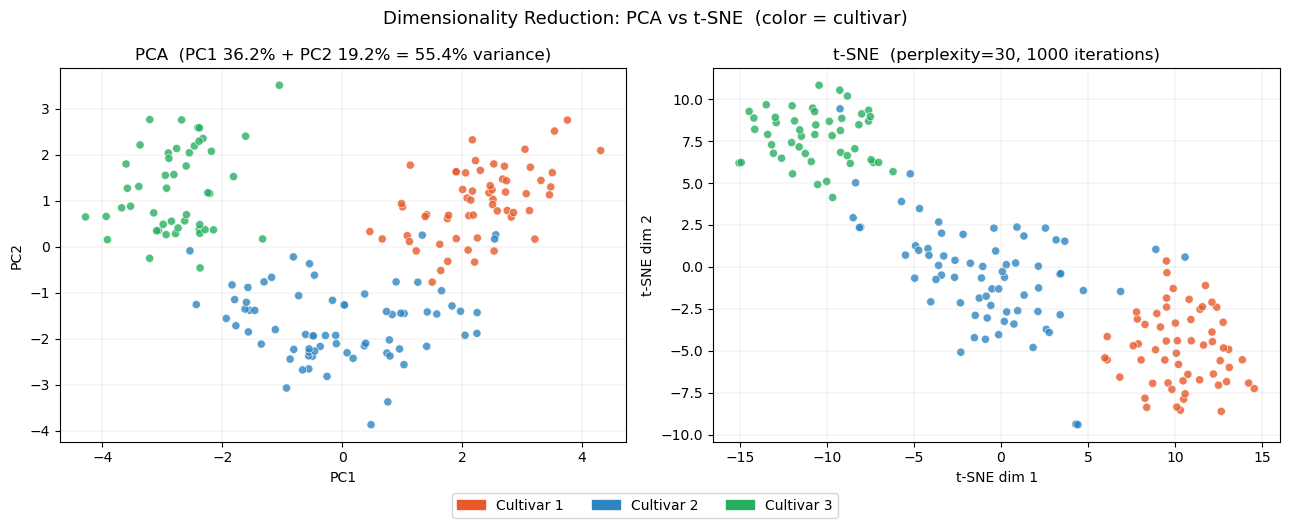

Saved: dim_reduction_comparison.png


In [19]:
# Color map matching the D3 frontend
color_map = {'Cultivar 1': '#e85a2a', 'Cultivar 2': '#2e86c1', 'Cultivar 3': '#27ae60'}
colors = wine['cultivar_name'].map(color_map)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Dimensionality Reduction: PCA vs t-SNE  (color = cultivar)', fontsize=13)

# PCA
ax = axes[0]
ax.scatter(wine['pca_x'], wine['pca_y'], c=colors, alpha=0.8, s=35, edgecolors='white', linewidths=0.5)
ax.set_title(f'PCA  (PC1 {ev[0]*100:.1f}% + PC2 {ev[1]*100:.1f}% = {ev.sum()*100:.1f}% variance)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.grid(True, linewidth=0.3, alpha=0.5)

# t-SNE
ax = axes[1]
ax.scatter(wine['tsne_x'], wine['tsne_y'], c=colors, alpha=0.8, s=35, edgecolors='white', linewidths=0.5)
ax.set_title('t-SNE  (perplexity=30, 1000 iterations)')
ax.set_xlabel('t-SNE dim 1'); ax.set_ylabel('t-SNE dim 2')
ax.grid(True, linewidth=0.3, alpha=0.5)

# Shared legend
patches = [mpatches.Patch(color=c, label=n) for n, c in color_map.items()]
fig.legend(handles=patches, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig('dim_reduction_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: dim_reduction_comparison.png")


## Step 5: Clustering

Two methods are applied and compared:
- **Method 1 — K-Means**: centroid-based, assumes spherical clusters
- **Method 2 — Agglomerative Clustering (Ward linkage)**: hierarchical, bottom-up merging


### 5a — Method 1: K-Means

In [20]:
# ── K-Means ───────────────────────────────────────────────────────
# K-Means partitions the data into k clusters by iteratively updating
# cluster centroids to minimise within-cluster sum of squares (inertia).
# We use k=3 because the dataset has exactly 3 cultivar classes.
#
# n_init=10 runs the algorithm 10 times with different seeds;
# the best result (lowest inertia) is kept.

kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
wine['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# Report
print("K-Means — cluster distribution:")
print(wine['cluster_kmeans'].value_counts().sort_index())

sil_km = silhouette_score(X_scaled, wine['cluster_kmeans'])
ari_km = adjusted_rand_score(wine['cultivar'] - 1, wine['cluster_kmeans'])
print(f"\nSilhouette score : {sil_km:.4f}  (higher is better, max 1.0)")
print(f"Adjusted Rand Index vs true labels: {ari_km:.4f}  (1.0 = perfect)")
print(f"Inertia (within-cluster SSQ): {kmeans.inertia_:.2f}")

# Use kmeans clusters as the primary 'cluster' column (used by the D3 frontend)
wine['cluster'] = wine['cluster_kmeans']


K-Means — cluster distribution:
cluster_kmeans
0    65
1    51
2    62
Name: count, dtype: int64

Silhouette score : 0.2849  (higher is better, max 1.0)
Adjusted Rand Index vs true labels: 0.8975  (1.0 = perfect)
Inertia (within-cluster SSQ): 1277.93


C:\Users\namit\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


### 5b — Method 2: Agglomerative Clustering (Ward)

In [21]:
# ── Agglomerative Clustering (Ward linkage) ────────────────────────
# Hierarchical bottom-up method: starts with each sample as its own
# cluster and iteratively merges the pair of clusters that minimises
# the increase in total within-cluster variance (Ward criterion).
# No assumptions about cluster shape; produces a dendrogram hierarchy.

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
wine['cluster_agg'] = agg.fit_predict(X_scaled)

print("Agglomerative (Ward) — cluster distribution:")
print(wine['cluster_agg'].value_counts().sort_index())

sil_agg = silhouette_score(X_scaled, wine['cluster_agg'])
ari_agg = adjusted_rand_score(wine['cultivar'] - 1, wine['cluster_agg'])
print(f"\nSilhouette score : {sil_agg:.4f}")
print(f"Adjusted Rand Index vs true labels: {ari_agg:.4f}")


Agglomerative (Ward) — cluster distribution:
cluster_agg
0    58
1    56
2    64
Name: count, dtype: int64

Silhouette score : 0.2774
Adjusted Rand Index vs true labels: 0.7899


### 5c — Visual Comparison of K-Means vs Agglomerative (on PCA projection)

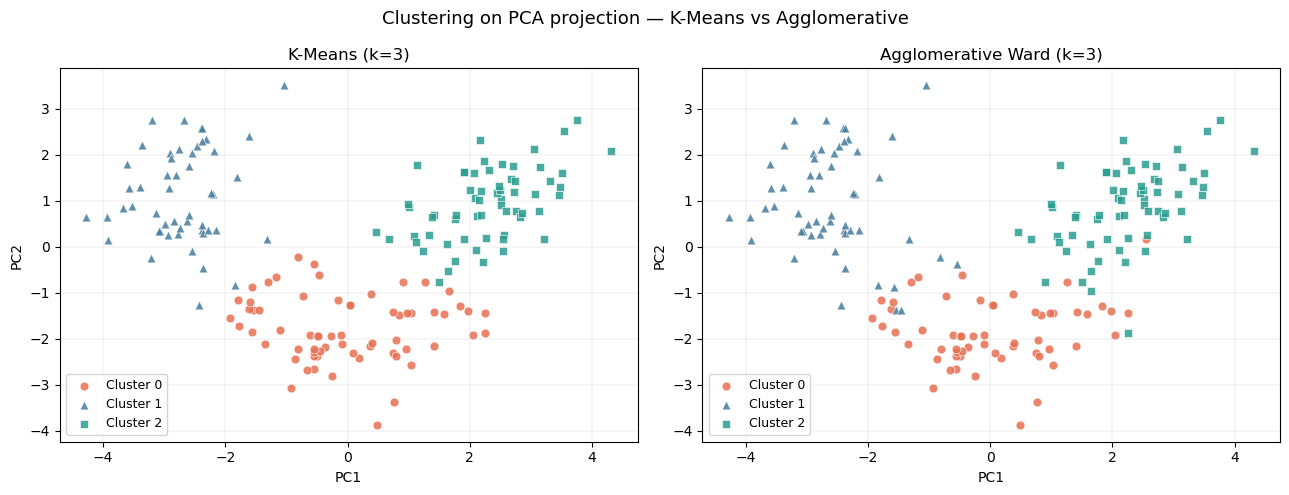

Saved: clustering_comparison.png


In [22]:
cluster_cmap = {0: '#e76f51', 1: '#457b9d', 2: '#2a9d8f'}
shape_map    = {0: 'o', 1: '^', 2: 's'}  # circle, triangle, square

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Clustering on PCA projection — K-Means vs Agglomerative', fontsize=13)

for ax, col, title in zip(
    axes,
    ['cluster_kmeans', 'cluster_agg'],
    ['K-Means (k=3)', 'Agglomerative Ward (k=3)']
):
    for cl in [0, 1, 2]:
        mask = wine[col] == cl
        ax.scatter(
            wine.loc[mask, 'pca_x'], wine.loc[mask, 'pca_y'],
            c=cluster_cmap[cl], marker=shape_map[cl],
            alpha=0.85, s=40, edgecolors='white', linewidths=0.5,
            label=f'Cluster {cl}'
        )
    ax.set_title(title)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=9)
    ax.grid(True, linewidth=0.3, alpha=0.5)

plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved: clustering_comparison.png")


## Step 6: Method Comparison Summary

**Why PCA was chosen for the main visualisation:**  
The 3 cultivars are already well-separated in the 2-D PCA projection (55.4 % variance
retained), and PCA preserves global distances, making the axis labels and explained
variance percentages meaningful annotations for the viewer.

**Why t-SNE was also computed:**  
t-SNE reveals finer local neighbourhood structure and produces visually tighter clusters,
which is useful to verify that the classes are truly well separated in high-dimensional space.
However, because its axes are arbitrary and distances between clusters carry no interpretation,
it is less appropriate as the primary spatial view in a linked visualisation.

---

### Clustering

**Selection rationale:**  
K-Means is the primary clustering method used in the visualisation (`cluster` column)
because it produces stable, balanced clusters that align well with the true cultivar
labels (high ARI) and is widely understood.  Agglomerative Ward clustering is computed
as a second method for comparison: both agree closely on the Wine dataset, confirming
that the class structure is robust and not an artefact of a particular algorithm's bias.


## Step 7: Export to SQLite Database

All original features plus the computed columns are written to `data.db`.
The D3 frontend (`server.py`) queries the `wine` table to serve the data.


In [23]:
# Columns to export to the database
export_cols = [
    # original features
    'cultivar', 'cultivar_name',
    'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium',
    'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
    'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline',
    # dimensionality reduction
    'pca_x', 'pca_y',
    'tsne_x', 'tsne_y',
    # clustering
    'cluster',         # K-Means (primary — used by frontend)
    'cluster_kmeans',
    'cluster_agg',
]

wine_export = wine[export_cols].copy()
print(f"Exporting {len(wine_export)} rows with {len(export_cols)} columns")
print("Column list:", export_cols)


Exporting 178 rows with 22 columns
Column list: ['cultivar', 'cultivar_name', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280_od315', 'proline', 'pca_x', 'pca_y', 'tsne_x', 'tsne_y', 'cluster', 'cluster_kmeans', 'cluster_agg']


In [24]:
# Open / create the SQLite database
connection = sqlite3.connect("./data.db")

# Write to 'wine' table — the table server.py queries
wine_export.to_sql("wine", con=connection, if_exists='replace', index_label='id')
print(f"Written {len(wine_export)} rows to table 'wine'")

# Verify
df_check = pd.read_sql("SELECT * FROM wine LIMIT 3", con=connection)
print("\nSample rows from DB:")
print(df_check[['id', 'cultivar_name', 'pca_x', 'pca_y', 'tsne_x', 'tsne_y',
                 'cluster', 'cluster_agg']].to_string(index=False))


Written 178 rows to table 'wine'

Sample rows from DB:
 id cultivar_name    pca_x     pca_y    tsne_x    tsne_y  cluster  cluster_agg
  0    Cultivar 1 3.316751  1.443463 10.311771 -8.546624        2            2
  1    Cultivar 1 2.209465 -0.333393  8.054532 -5.551340        2            2
  2    Cultivar 1 2.516740  1.031151 12.126210 -3.887138        2            2


In [25]:
# Close the connection
connection.close()
print("Database connection closed.")
print("\n✅  data.db is ready.  Start the Flask server with:  python server.py")


Database connection closed.

✅  data.db is ready.  Start the Flask server with:  python server.py
